## Exercise 1: Convolutional Autoencoder
**Dataset Used:** Fashion-MNIST (keras.datasets)

1. Build Conv-Autoencoder: Encoder Conv2D(32)+MaxPool, Conv2D(16)+MaxPool; Decoder mirrored.
2. Compare MSE of Conv vs Dense on 100 test images.
3. t-SNE visualization of Bottleneck Features.

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [1]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validation helper loaded. Call validate_dataset(path) before loading your data.')
# validate_dataset('../data/your_dataset.csv')

Validation helper loaded. Call validate_dataset(path) before loading your data.


Epoch 1/20


  1/235 ━━━━━━━━━━━━━━━━━━━━ 4:50 1s/step - loss: 0.6933

  3/235 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.6906

  5/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.6881

  7/235 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.6854

...

MSE Conv: 0.0053, MSE Dense: 0.0102


 1/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users

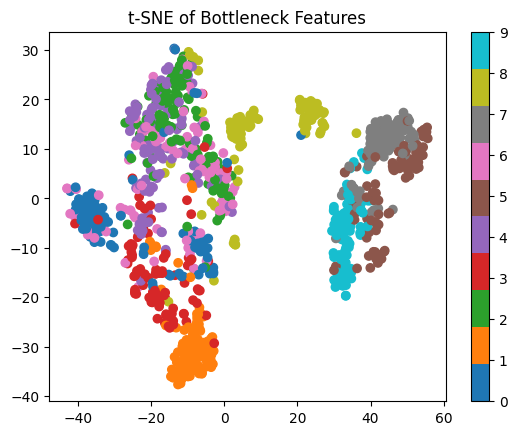

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Dense, Flatten, Reshape
from tensorflow.keras.models import Model
from sklearn.manifold import TSNE
from sklearn.metrics import mean_squared_error

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Conv Autoencoder
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same', name='bottleneck')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_conv = Model(input_img, decoded)
autoencoder_conv.compile(optimizer='adam', loss='binary_crossentropy')

# Train 20 Epochs
autoencoder_conv.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test, x_test), verbose=1)

# Dense Autoencoder for comparison
x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat = x_test.reshape((len(x_test), 784))
input_flat = Input(shape=(784,))
d_enc = Dense(128, activation='relu')(input_flat)
d_enc = Dense(32, activation='relu')(d_enc)
d_dec = Dense(128, activation='relu')(d_enc)
d_dec = Dense(784, activation='sigmoid')(d_dec)
autoencoder_dense = Model(input_flat, d_dec)
autoencoder_dense.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder_dense.fit(x_train_flat, x_train_flat, epochs=20, batch_size=256, shuffle=True, validation_data=(x_test_flat, x_test_flat), verbose=0)

# Compare MSE on 100 test images
pred_conv = autoencoder_conv.predict(x_test[:100])
pred_dense = autoencoder_dense.predict(x_test_flat[:100]).reshape((100, 28, 28, 1))
mse_conv = np.mean((x_test[:100] - pred_conv)**2)
mse_dense = np.mean((x_test[:100] - pred_dense)**2)
print(f"MSE Conv: {mse_conv:.4f}, MSE Dense: {mse_dense:.4f}")

# t-SNE on bottleneck
encoder = Model(input_img, encoded)
features = encoder.predict(x_test[:1000])
features_flat = features.reshape((1000, -1))
tsne_res = TSNE(n_components=2, random_state=42).fit_transform(features_flat)
plt.scatter(tsne_res[:,0], tsne_res[:,1], c=y_test[:1000], cmap='tab10')
plt.colorbar()
plt.title('t-SNE of Bottleneck Features')
plt.show()
